# Welcome to Viewport
## A world dedicated for quick experiment and data visualization

In [1]:
from chunker import Chunker
from collector import Collector
from rag import Augmentor, Retriever, Judger

In [5]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./chroma_db")
collection = chroma_client.get_collection("policy_procedures")
data = collection.get( include=["embeddings", "metadatas", "documents"] )

len(data["documents"])

204

In [7]:
import numpy as np

emb = data["embeddings"]          # lista di liste
ids = data["ids"]
metas = data.get("metadatas", None)

X = np.array(emb, dtype=np.float32)
print("shape:", X.shape)          # (n_points, dim)


shape: (204, 384)


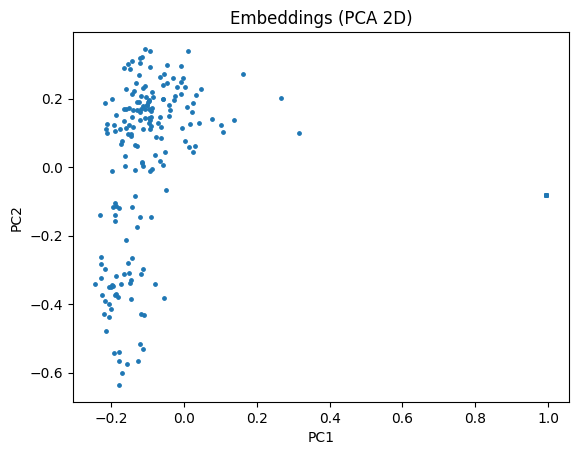

Explained variance ratio: [0.15998271 0.08121758]


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)

plt.figure()
plt.scatter(X2[:,0], X2[:,1], s=6)
plt.title("Embeddings (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


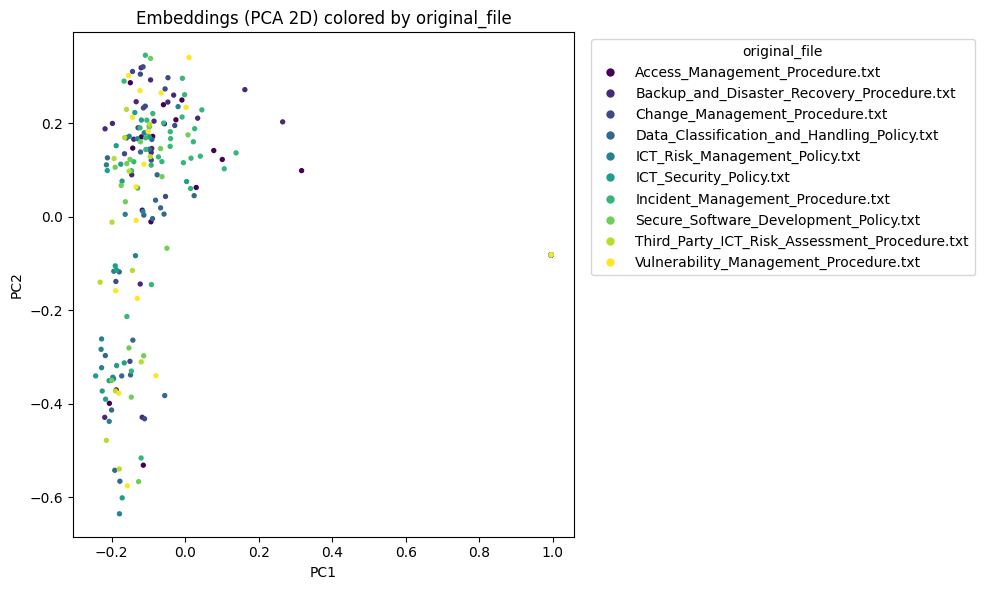

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

key = "original_file"
labels = [m.get(key, "NA") if m else "NA" for m in metas]

uniq = {v:i for i,v in enumerate(sorted(set(labels)))}
c = np.array([uniq[v] for v in labels])

plt.figure(figsize=(10,6))
sc = plt.scatter(X2[:,0], X2[:,1], s=8, c=c)
plt.title(f"Embeddings (PCA 2D) colored by {key}")
plt.xlabel("PC1"); plt.ylabel("PC2")

# legenda
inv = {i:lab for lab,i in uniq.items()}  # int -> label
handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markersize=6,
           markerfacecolor=sc.cmap(sc.norm(i)),
           markeredgecolor='none',
           label=inv[i])
    for i in range(len(inv))
]
plt.legend(handles=handles, title=key, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 1) Riduzione a 3D
pca3 = PCA(n_components=3, random_state=0)
X3 = pca3.fit_transform(X)   # X = embeddings (n, dim)

# 2) Colori per metadata
key = "original_file"
labels = [m.get(key, "NA") if m else "NA" for m in metas]

uniq = {v:i for i,v in enumerate(sorted(set(labels)))}
c = np.array([uniq[v] for v in labels])

# 3) Plot 3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=8, c=c)
ax.set_title(f"Embeddings (PCA 3D) colored by {key}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")

# Legenda
inv = {i:lab for lab,i in uniq.items()}  # int -> label
handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markersize=6,
           markerfacecolor=sc.cmap(sc.norm(i)),
           markeredgecolor='none',
           label=inv[i])
    for i in range(len(inv))
]
ax.legend(handles=handles, title=key, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>